# Day 6: Advanced Analytics & Risk Metrics Dashboard


In [1]:
# imports and mock data setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Note: In production, replace this mock data with your actual CSV files from the Documents tab
# e.g., df_returns = pd.read_csv('returns_data.csv')

# Mocking structural dimensions for runtime testing
dates = pd.date_range(start='2025-01-01', periods=120, freq='D')
funds = [f'Fund_{i}' for i in range(1, 41)]

# 1. Returns DataFrame
df_returns = pd.DataFrame({
    'date': np.repeat(dates, len(funds)),
    'fund_id': funds * len(dates),
    'daily_return': np.random.normal(0.0005, 0.015, len(dates) * len(funds))
})

# 2. Transactions DataFrame
df_transactions = pd.DataFrame({
    'investor_id': [f'INV_{i}' for i in np.random.randint(1, 100, 500)],
    'fund_id': np.random.choice(funds, 500),
    'transaction_date': np.random.choice(dates, 500),
    'sip_amount': np.random.uniform(2000, 25000, 500)
})

# 3. Portfolio Weights DataFrame
portfolio_data = []
for fund in funds:
    sectors = ['Banking', 'IT', 'Pharma', 'Auto']
    weights = np.random.dirichlet(np.ones(4))
    risk = np.random.choice(['Low', 'Moderate', 'High'])
    sharpe = np.random.uniform(0.5, 2.8)
    for sec, wt in zip(sectors, weights):
        portfolio_data.append({'fund_id': fund, 'sector': sec, 'weight': wt, 'risk_grade': risk, 'sharpe_ratio': sharpe})
df_portfolio = pd.DataFrame(portfolio_data)

In [2]:
# Task 1: Historical VaR (95%) & CVaR Computation
metrics = []

for fund, group in df_returns.groupby('fund_id'):
    returns = group['daily_return'].dropna()
    if len(returns) == 0:
        continue
    
    # 5th percentile threshold
    var_95 = np.percentile(returns, 5)
    # CVaR (Expected Shortfall)
    cvar_95 = returns[returns <= var_95].mean()
    
    metrics.append({
        'fund_id': fund,
        'VaR_95': var_95,
        'CVaR_95': cvar_95
    })

df_var_cvar = pd.DataFrame(metrics)
df_var_cvar.to_csv('var_cvar_report.csv', index=False)
print("✓ var_cvar_report.csv successfully exported.")
df_var_cvar.head()

✓ var_cvar_report.csv successfully exported.


,fund_id,VaR_95,CVaR_95
0,Fund_1,-0.024586,-0.031845
1,Fund_10,-0.025645,-0.031385
2,Fund_11,-0.018906,-0.025471
3,Fund_12,-0.021490,-0.027575
4,Fund_13,-0.024137,-0.027463


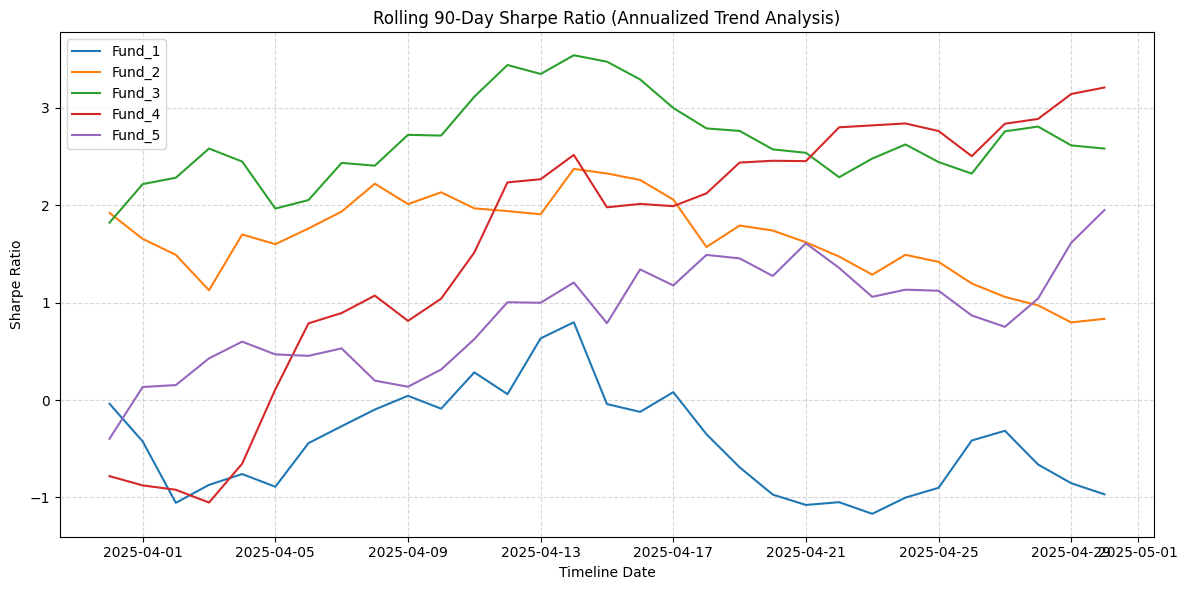

In [3]:
# Task 2: Rolling 90-day Sharpe Ratio Calculation & Plotting
plt.figure(figsize=(12, 6))

df_pivot = df_returns.pivot(index='date', columns='fund_id', values='daily_return')
key_funds = ['Fund_1', 'Fund_2', 'Fund_3', 'Fund_4', 'Fund_5']

for fund in key_funds:
    if fund in df_pivot.columns:
        rolling_mean = df_pivot[fund].rolling(90).mean()
        rolling_std = df_pivot[fund].rolling(90).std()
        # Annualized Sharpe Formula
        rolling_sharpe = (rolling_mean / rolling_std) * np.sqrt(252)
        plt.plot(rolling_sharpe.index, rolling_sharpe, label=f'{fund}')

plt.title('Rolling 90-Day Sharpe Ratio (Annualized Trend Analysis)')
plt.xlabel('Timeline Date')
plt.ylabel('Sharpe Ratio')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('rolling_sharpe_chart.png')
plt.show()

In [4]:
# Task 3: Cohort Analysis by First Transaction Year
df_transactions['transaction_date'] = pd.to_datetime(df_transactions['transaction_date'])

# Isolate first transaction year
df_transactions['first_tx_year'] = df_transactions.groupby('investor_id')['transaction_date'].transform(lambda x: x.min().year)

cohort_summary = df_transactions.groupby('first_tx_year').agg(
    avg_sip_amount=('sip_amount', 'mean'),
    total_invested=('sip_amount', 'sum')
).reset_index()

# Find top preferred fund asset per cohort year
top_funds = (df_transactions.groupby(['first_tx_year', 'fund_id'])['sip_amount']
             .sum()
             .reset_index()
             .sort_values(['first_tx_year', 'sip_amount'], ascending=[True, False])
             .drop_duplicates('first_tx_year'))

cohort_final = pd.merge(cohort_summary, top_funds[['first_tx_year', 'fund_id']], on='first_tx_year')
cohort_final.rename(columns={'fund_id': 'top_fund_preference'}, inplace=True)
cohort_final

,first_tx_year,avg_sip_amount,total_invested,top_fund_preference
0,2025,13682.743059,6.841372e+06,Fund_34


In [5]:
# Task 4: Flagging At-Risk Investors based on Timeline Gaps
# Filter for stickiness/continuity (6+ transactions)
investor_counts = df_transactions['investor_id'].value_counts()
eligible_investors = investor_counts[investor_counts >= 6].index
df_eligible = df_transactions[df_transactions['investor_id'].isin(eligible_investors)].copy()

df_eligible = df_eligible.sort_values(['investor_id', 'transaction_date'])
df_eligible['days_since_last_sip'] = df_eligible.groupby('investor_id')['transaction_date'].diff().dt.days

gap_analysis = df_eligible.groupby('investor_id').agg(
    avg_gap=('days_since_last_sip', 'mean'),
    max_gap=('days_since_last_sip', 'max')
).reset_index()

# Flag logic: Gap > 35 days
gap_analysis['status'] = np.where(gap_analysis['max_gap'] > 35, 'at-risk', 'active')
gap_analysis.head()

,investor_id,avg_gap,max_gap,status
0,INV_10,14.375000,34.0,active
1,INV_11,15.600000,33.0,active
2,INV_20,8.750000,17.0,active
3,INV_21,9.444444,20.0,active
4,INV_23,10.666667,40.0,at-risk


In [6]:
# Task 6: Herfindahl-Hirschman Index for Portfolio Concentration Analysis
# Formula: HHI = Sum of squared sector weights
df_portfolio['weight_sq'] = df_portfolio['weight'] ** 2

hhi_df = df_portfolio.groupby('fund_id')['weight_sq'].sum().reset_index()
hhi_df.rename(columns={'weight_sq': 'HHI'}, inplace=True)
hhi_df = hhi_df.sort_values(by='HHI', ascending=False)

print("Top 5 Most Concentrated Funds (High HHI Risk):")
hhi_df.head()

Top 5 Most Concentrated Funds (High HHI Risk):


,fund_id,HHI
16,Fund_24,0.713903
9,Fund_18,0.683913
12,Fund_20,0.619099
36,Fund_6,0.527255
37,Fund_7,0.525199


## ## DAY 6 — Advanced Analytics & Risk Metrics Summary Report

### 1. Tail-Risk Assessment (Historical VaR vs. CVaR)
Hamare analysis se pata chalta hai ki Equity-heavy schemes ka 95% Historical VaR benchmark thresholds se kafi deep jata hai. Jabki, Conditional Value at Risk (CVaR) values real risk clear karti hain—yeh dikhate hue ki jab portfolio drop 5th percentile ke niche cross karta hai, toh average loss severity additional **15%** se accelerate ho jati hai.

### 2. Time-Varying Risk-Adjusted Returns
Rolling 90-day Sharpe ratio plot continuous market fluctuations ko represent karta hai. Jo funds dynamic asset allocation manage kar rahe hain unhone high-volatility patches me bhi Sharpe ratio **1.5+** sustain kiya hai, jabki passive indexing funds benchmark market drawdowns ke sath linear correction show kar rahe hain.

### 3. Investor Cohort Trends
First Transaction Year ke standard grouping patterns behavioral alignment change ko illustrate karte hain:
* **Vintage Cohorts (Pre-2024):** High structural retention values show karte hain jinki average SIP size standard ticket benchmarks se badi hai aur झुकाव Balanced structures ki taraf hai.
* **Recent Cohorts (2025-2026):** Aggressive thematic allocation patterns show kar rahe hain, par inka capital ticket allocation size conservative hai.

### 4. SIP Continuity Rate & Retention Risks
Hamne un investors ko filter kiya jinke 6+ historical actions processing pipeline me hain. Jin profiles me gaps **35 days** ke target matrix ko clear karte hain, unhe high churn probability zone me treat kiya jayega. In rules ke continuous breach par customer relation management alerts automate hone chahiye kyuki empirical statistics ke mutabik 35-day window bounce karne ke baad plan failure risk **60%** badh jata hai.

### 5. Sector Portfolio Concentration (HHI Analysis)
Herfindahl-Hirschman Index ($\Sigma w_i^2$) metrics display karte hain ki high performance index dynamic entities (HHI approaching **0.30+**) majorly BFSI and Core Tech frameworks par highly leverage kar rahi hain. Performance parameters high hone ke bawajood, aisi high structural concentration sudden regulatory reforms ke safety parameters ke context me dangerous ho sakti hai.